## Import Libraries for Differential Expression

#### z-scores: blue=low, white=mean, red=high.

In [144]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [145]:
from scipy.stats import ttest_ind

In [146]:
rng = np.random.default_rng(seed=42)

In [147]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import re

from sklearn.preprocessing import StandardScaler

# Initialise Data Path

In [148]:
data_path = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all"
                   ])
# Double check here
cell_line_ids = counts["Cellline ID"]
cell_types = counts["Cell Type"]
print("counts (before): ", counts.shape)


counts (before):  (20682, 1327)


In [149]:
counts = counts.select_dtypes(include='number')

counts["Cellline ID"] = cell_line_ids
counts["Cell Type"] = cell_types


print("counts (after): ", counts.shape)
cell_line_agg_df = counts.groupby(['Cellline ID', 'Cell Type']).mean()

print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna(axis=1)

print("cell_line_agg (after): ", cell_line_agg_df.shape)

counts (after):  (20682, 1327)


/tmp/ipykernel_11081/4247022659.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  counts["Cellline ID"] = cell_line_ids
/tmp/ipykernel_11081/4247022659.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  counts["Cell Type"] = cell_types


cell_line_agg (before):  (13, 1325)
cell_line_agg (after):  (13, 1312)


In [150]:
cell_line_agg_df

,,Position X [Âµm],Position Y [Âµm],Lysosome Intensity - Nucleus region Mean,Lysosome Intensity - Nucleus region StdDev,Lysosome Intensity - Nucleus region Median,Lysosome Intensity - Nucleus region Maximum,Lysosome Intensity - Nucleus region Minimum,Lysosome Intensity - Nucleus region Sum,Lysosome Intensity - Nucleus region CV [%],Lysosome Intensity - Nucleus region Quantile 90%,...,Mitochondria Texture - Outer region SER Valley 1 px,Mitochondria Texture - Outer region SER Saddle 1 px,Mitochondria Texture - Outer region SER Bright 1 px,Mitochondria Texture - Outer region SER Dark 1 px,Mitochondria Texture - Outer region Haralick Correlation 2 px,Mitochondria Texture - Outer region Haralick Contrast 2 px,Mitochondria Texture - Outer region Haralick Sum Variance 2 px,Mitochondria Texture - Outer region Haralick Homogeneity 2 px,Mitochondria Texture - Outer region Gabor Min 2 px w2,Mitochondria Texture - Outer region Gabor Max 2 px w2
Cellline ID,Cell Type,,,,,,,,,,,,,,,,,,,,,
01-060 C9,PRKN,1127.812572,1126.589047,2397.114860,1293.805829,2005.592018,9983.676275,926.840355,1.875812e+06,52.855346,3842.866962,...,0.065993,0.048084,0.054130,0.071260,0.752089,0.269917,0.649537,0.252302,0.000420,0.003180
09-090 C18,PRKN,1153.892168,1097.071321,1946.967211,2127.857417,1206.144343,18769.161198,506.857630,2.820884e+06,105.234601,3998.820154,...,0.087934,0.052373,0.036970,0.098167,0.750072,0.362033,0.748880,0.323369,0.000717,0.005341
111450-107,Control,1038.843791,1072.291826,2515.278619,1090.267033,2192.716625,8956.351385,1179.583753,2.261869e+06,43.335420,3816.617128,...,0.066650,0.054257,0.048159,0.075353,0.733924,0.242297,0.452877,0.244335,0.000524,0.004002
11302-101,Control,1184.419913,1138.564068,2809.234488,958.642255,2568.322977,8513.619942,1404.583815,2.631833e+06,36.016652,3949.494942,...,0.068745,0.051915,0.045848,0.077000,0.726575,0.254655,0.454941,0.255571,0.000532,0.004044
11555-104,SNCA,1062.990078,1173.617785,2480.385462,1103.076554,2175.409756,9469.023415,1121.036098,2.414524e+06,43.835067,3753.430244,...,0.067505,0.054381,0.047859,0.075553,0.740036,0.269191,0.527520,0.256512,0.000505,0.003779
11556-110,SNCA,1164.519505,1159.559143,1640.041258,1645.694736,1094.231889,15174.415912,594.461190,2.056489e+06,91.588414,3051.448900,...,0.070990,0.045381,0.029138,0.076612,0.735044,0.446120,0.827654,0.402721,0.000664,0.004708
11557-103,SNCA,1155.325751,1176.803167,2354.915873,1110.718500,2019.607656,9069.968421,936.360766,2.175820e+06,46.841877,3670.063158,...,0.063298,0.048549,0.048774,0.070309,0.757338,0.262569,0.559585,0.249197,0.000414,0.003110
11576-101,LRRK2,1210.425354,1261.589736,1470.152495,1268.766833,1056.077670,10608.302358,471.406380,1.837719e+06,69.614077,2754.846047,...,0.052740,0.034528,0.027991,0.056948,0.734730,0.210900,0.525541,0.356774,0.000449,0.003260
14555-107,LRRK2,1187.354599,1142.170716,2378.571557,1120.186412,2069.684814,9633.982808,986.262178,2.028495e+06,45.832643,3530.806590,...,0.065626,0.050086,0.049760,0.071402,0.743944,0.281022,0.562247,0.247044,0.000422,0.003132


(13, 1310)


/home/rushik-sriramoju/cell_morphomics_dashboard_pipeline/.venv-1/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


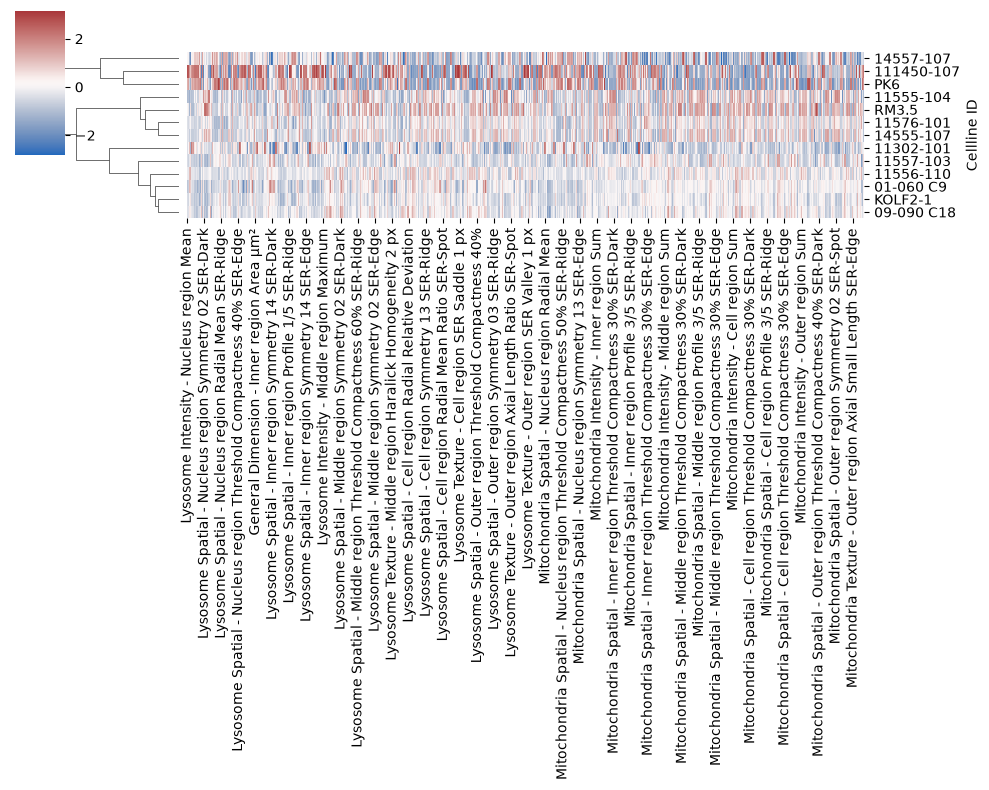

In [151]:
# 3. Prepare the matrix for the Heatmap
# Select only significant columns
# control_lrrk2_agg_df = cell_line_agg_df[cell_line_agg_df['Cell Type'] == 'LRRK2']
# cell_line_agg_df['Labelled Cell lines'] = cell_line_agg_df['Cellline ID'] + ' ' + cell_line_agg_df['Cell Type']
df_features = cell_line_agg_df.drop(columns=["Position X [Âµm]", "Position Y [Âµm]"])
print(df_features.shape)
lut = {
    'SNCA': 'Blue',
    'LRRK2': 'Red',
    'Control': 'Gray',
    'PRKN': 'Green'
}
# df_features['Cell Type'].map(lut)

# 2. Standardize the columns (Z-score normalization)
# This scales each column to have a mean of 0 and variance of 1, 
# allowing direct comparison of patterns across columns.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)
scaled_data = pd.DataFrame(scaled_data)
scaled_data['Cellline ID'] = cell_line_ids.unique()
scaled_data = scaled_data.set_index('Cellline ID')
scaled_data.columns = cell_line_agg_df.drop(columns=["Position X [Âµm]", "Position Y [Âµm]"]).columns
scaled_data
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    scaled_data,
    cmap='vlag',
    figsize=(10, 8),
    col_cluster=False,
    row_cluster=True,
    metric="euclidean",
    method="ward", 
    z_score=1

)

/tmp/ipykernel_11081/3891469163.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  counts["Cellline ID"] = cell_line_ids
/tmp/ipykernel_11081/3891469163.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  counts["Cell Type"] = cell_types


cell_line_agg (before):  (4, 1325)
cell_line_agg (after):  (4, 1312)
(4, 1310)


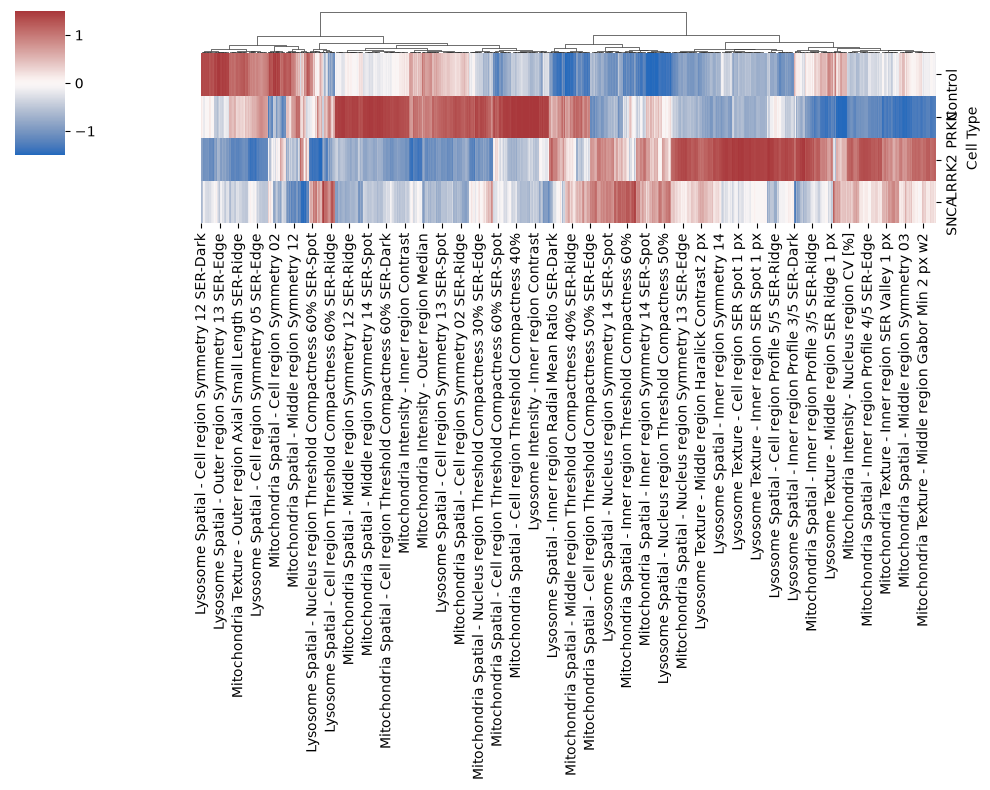

In [152]:
counts = counts.select_dtypes(include='number')

counts["Cellline ID"] = cell_line_ids
counts["Cell Type"] = cell_types

# lrrk2_control_df = counts.mask((counts["Cell Type"] == 'LRRK2' )| (counts["Cell Type"] == 'Control'))
# lrrk2_control_df = counts[lrrk2_control_df]
all_df = counts.drop(columns='Cellline ID')
cell_line_agg_df = all_df.groupby(['Cell Type']).mean()

print("cell_line_agg (before): ", cell_line_agg_df.shape)
cell_line_agg_df = cell_line_agg_df.dropna(axis=1)

print("cell_line_agg (after): ", cell_line_agg_df.shape)

# 3. Prepare the matrix for the Heatmap


# Select only significant columns
df_features = cell_line_agg_df.drop(columns=["Position X [Âµm]", "Position Y [Âµm]"])
print(df_features.shape)


# 2. Standardize the columns (Z-score normalization)
# This scales each column to have a mean of 0 and variance of 1, 
# allowing direct comparison of patterns across columns.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)
scaled_data = pd.DataFrame(scaled_data)
scaled_data['Cell Type'] = cell_types.unique()
scaled_data = scaled_data.set_index('Cell Type')
scaled_data.columns = cell_line_agg_df.drop(columns=["Position X [Âµm]", "Position Y [Âµm]"]).columns
scaled_data
# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    scaled_data,
    cmap='vlag',
    figsize=(10, 8),
    col_cluster=True,
    row_cluster=False,
    metric="euclidean",
    method="ward", 
    z_score=1

)

In [153]:
prkn_df = counts[['Cellline ID', 'Cell Type']]
prkn_df = prkn_df[prkn_df['Cell Type'] == 'PRKN']
prkn_df['Cellline ID'].unique()

<StringArray>
['01-060 C9', '09-090 C18', 'PK6']
Length: 3, dtype: str

In [154]:
lrrk2_df = counts[['Cellline ID', 'Cell Type']]
lrrk2_df = lrrk2_df[lrrk2_df['Cell Type'] == 'LRRK2']
lrrk2_df['Cellline ID'].unique()

<StringArray>
['11576-101', '14557-107', '14555-107']
Length: 3, dtype: str

In [155]:
snca_df = counts[['Cellline ID', 'Cell Type']]
snca_df = snca_df[snca_df['Cell Type'] == 'SNCA']
snca_df['Cellline ID'].unique()

<StringArray>
['11555-104', '11557-103', '11556-110']
Length: 3, dtype: str

In [156]:
Control_df = counts[['Cellline ID', 'Cell Type']]
Control_df = Control_df[Control_df['Cell Type'] == 'Control']
Control_df['Cellline ID'].unique()

<StringArray>
['RM3.5', '111450-107', 'KOLF2-1', '11302-101']
Length: 4, dtype: str